# Autonomous Cleaning Robot: Reinforcement Learning with Battery Management

## Project Overview

We train a Roomba-style vacuum cleaning robot using tabular reinforcement learning. The robot **cleans automatically as it moves** — its real decisions are **where to go** and **when to recharge**.

### Key Design Choices
- **Auto-clean on move**: No explicit "Clean" action. Moving onto a dirty tile cleans it.
- **Partial observability**: The agent sees `(row, col, battery_bin)` but NOT the dirt grid. It must learn dirt patterns through reward signals.
- **Battery constraint**: 50 steps of battery on a 10x10 grid. The agent must learn to recharge without hard-coded heuristics.

### Research Questions
1. **Exploration strategies under battery constraint**: Which exploration method (Epsilon-Greedy, UCB, Optimistic Initialization) best handles the battery constraint?
2. **Q-Learning vs SARSA for risk-sensitive tasks**: Q-Learning (off-policy, optimistic) vs SARSA (on-policy, cautious) — which better manages catastrophic battery failure?

### Experiment Structure
- **Experiment 1**: Q-Learning with 3 exploration strategies — compare learning speed, coverage, and battery management
- **Experiment 2**: Best exploration strategy with Q-Learning vs SARSA — which algorithm handles battery risk better?
- **Experiment 3** (Phase 2): Scale up to realistic apartment with walls and doorways

---
## Setup

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

# Ensure v2/ modules are importable
sys.path.insert(0, '.')

from config import *
from environment import CleaningRobotEnv
from agents import QLearningAgent, SARSAAgent
from utils import (
    run_experiment, train_agent, create_agent, evaluate_agent,
    plot_learning_curves, plot_multi_metric, plot_coverage_heatmap,
    plot_battery_analysis, plot_evaluation_comparison, summary_table,
    plot_apartment_layout,
)

# Reproducibility
np.random.seed(42)

# Plot style
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print('Setup complete.')
print(f'Environment: {PHASE1_CONFIG["rows"]}x{PHASE1_CONFIG["cols"]} grid')
print(f'Battery capacity: {PHASE1_CONFIG["battery_capacity"]} steps')
print(f'Training episodes: {TRAINING_EPISODES}')
print(f'Random seeds: {SEEDS}')

Setup complete.
Environment: 10x10 grid
Battery capacity: 50 steps
Training episodes: 5000
Random seeds: [42, 123, 256, 789, 1024]


---
## Environment Demonstration

Let's first understand how the environment works before training any agents.

In [2]:
# Create environment and inspect initial state
env_demo = CleaningRobotEnv()
state = env_demo.reset(seed=42)

print(f'Environment: {env_demo}')
print(f'Initial state: {state}')
print(f'  -> (row={state[0]}, col={state[1]}, battery_bin={state[2]})')
print(f'State space size: {env_demo.num_states} states')
print(f'  -> {env_demo.rows} rows x {env_demo.cols} cols x {env_demo.battery_bins} battery bins')
print(f'Action space: {NUM_ACTIONS} actions — {ACTIONS}')
print(f'Total dirty tiles: {env_demo.total_dirty}')
print(f'Charger position: {env_demo.charger_pos}')
print()
print('Reward structure:')
for name, value in REWARDS.items():
    print(f'  {name:20s} = {value:+.1f}')

Environment: CleaningRobotEnv(10x10, battery=50/50, cleaned=0/99)
Initial state: (0, 0, 4)
  -> (row=0, col=0, battery_bin=4)
State space size: 500 states
  -> 10 rows x 10 cols x 5 battery bins
Action space: 5 actions — {0: 'Up', 1: 'Down', 2: 'Left', 3: 'Right', 4: 'Charge'}
Total dirty tiles: 99
Charger position: (0, 0)

Reward structure:
  clean_dirty          = +10.0
  step_cost            = -0.1
  wall_hit             = -2.0
  charge_success       = +5.0
  charge_full          = -1.0
  charge_away          = -5.0
  battery_dead         = -50.0


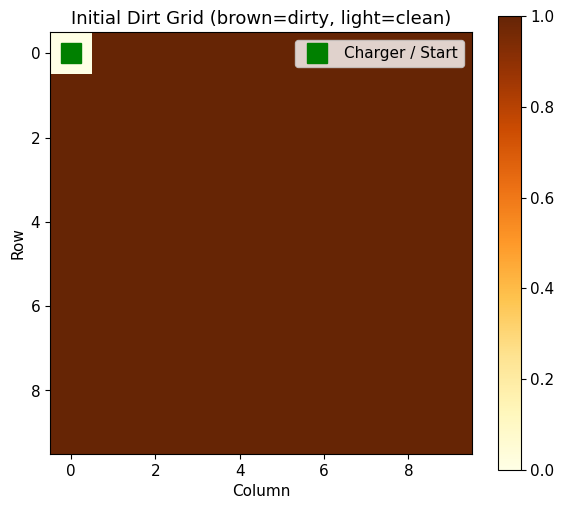

In [3]:
# Show initial dirt grid
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
dirt = env_demo.get_dirt_map()
im = ax.imshow(dirt, cmap='YlOrBr', vmin=0, vmax=1, origin='upper')
ax.set_title('Initial Dirt Grid (brown=dirty, light=clean)', fontsize=13)
ax.set_xlabel('Column')
ax.set_ylabel('Row')

# Mark charger and agent start
cr, cc = env_demo.charger_pos
ax.plot(cc, cr, 's', color='green', markersize=15, label='Charger / Start')
ax.legend(loc='upper right', fontsize=11)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

In [4]:
# Demonstrate a few manual steps
env_demo.reset(seed=42)
print('Manual walkthrough:')
print(f'Start: pos={env_demo.agent_pos}, battery={env_demo.battery}\n')

demo_actions = [
    (1, 'Down'),   # Move to dirty tile
    (3, 'Right'),  # Move to dirty tile
    (3, 'Right'),  # Move to dirty tile
    (4, 'Charge'), # Try to charge (away from charger)
    (0, 'Up'),     # Move to charger row
    (2, 'Left'),   # Move left
    (2, 'Left'),   # Back near charger
    (0, 'Up'),     # Back to charger tile
    (4, 'Charge'), # Charge at charger
]

for action_id, action_name in demo_actions:
    state, reward, done, info = env_demo.step(action_id)
    print(f'Action: {action_name:6s} -> state={state}, reward={reward:+6.1f}, '
          f'battery={info["battery"]}, event={info["event"]}')
    if done:
        print('Episode ended!')
        break

print(f'\nAfter walkthrough: {env_demo.cleaned_count}/{env_demo.total_dirty} tiles cleaned '
      f'({env_demo.get_coverage()*100:.1f}% coverage)')

Manual walkthrough:
Start: pos=(0, 0), battery=50

Action: Down   -> state=(1, 0, 4), reward= +10.0, battery=49, event=clean_dirty
Action: Right  -> state=(1, 1, 4), reward= +10.0, battery=48, event=clean_dirty
Action: Right  -> state=(1, 2, 4), reward= +10.0, battery=47, event=clean_dirty
Action: Charge -> state=(1, 2, 4), reward=  -5.0, battery=46, event=charge_away
Action: Up     -> state=(0, 2, 4), reward= +10.0, battery=45, event=clean_dirty
Action: Left   -> state=(0, 1, 4), reward= +10.0, battery=44, event=clean_dirty
Action: Left   -> state=(0, 0, 4), reward=  -0.1, battery=43, event=step_clean
Action: Up     -> state=(0, 0, 4), reward=  -2.0, battery=42, event=wall_hit
Action: Charge -> state=(0, 0, 4), reward=  +5.0, battery=50, event=charge_success

After walkthrough: 5/99 tiles cleaned (5.1% coverage)


---
## Experiment 1: Exploration Strategies Under Battery Constraint

We compare three exploration strategies, all using **Q-Learning**:

| Strategy | Description | Expected Behavior |
|----------|-------------|-------------------|
| **Epsilon-Greedy** | Random action with probability $\varepsilon$, decaying over time | Standard baseline. May waste battery on random moves early on. |
| **UCB** | Select action with highest $Q(s,a) + c\sqrt{\frac{\ln t}{N(s,a)}}$ | Systematic exploration. Tries all actions before exploiting. |
| **Optimistic Init** | Initialize $Q$-values high (15.0), use $\varepsilon$-greedy | Every action looks promising initially, agent tries everything. |

**Hypothesis**: UCB and Optimistic Initialization should learn battery management faster than Epsilon-Greedy, because they explore more systematically rather than randomly wasting battery.

In [5]:
# Experiment 1: Q-Learning with 3 exploration strategies
print('Running Experiment 1: Exploration Strategies (Q-Learning)')
print(f'Training for {TRAINING_EPISODES} episodes x {len(SEEDS)} seeds each...\n')

exp1_results = {}
exp1_agents = {}

# Epsilon-Greedy
print('Training Q-Learning + Epsilon-Greedy...')
metrics_eg, agents_eg = run_experiment('qlearning', 'epsilon_greedy')
exp1_results['Q-Learning + ε-Greedy'] = metrics_eg
exp1_agents['Q-Learning + ε-Greedy'] = agents_eg
print('  Done.')

# UCB
print('Training Q-Learning + UCB...')
metrics_ucb, agents_ucb = run_experiment('qlearning', 'ucb')
exp1_results['Q-Learning + UCB'] = metrics_ucb
exp1_agents['Q-Learning + UCB'] = agents_ucb
print('  Done.')

# Optimistic Initialization
print('Training Q-Learning + Optimistic Init...')
metrics_opt, agents_opt = run_experiment('qlearning', 'optimistic')
exp1_results['Q-Learning + Optimistic'] = metrics_opt
exp1_agents['Q-Learning + Optimistic'] = agents_opt
print('  Done.')

print('\nExperiment 1 complete!')

Running Experiment 1: Exploration Strategies (Q-Learning)
Training for 5000 episodes x 5 seeds each...

Training Q-Learning + Epsilon-Greedy...
  Done.
Training Q-Learning + UCB...
  Done.
Training Q-Learning + Optimistic Init...
  Done.

Experiment 1 complete!


### Experiment 1: Results

In [6]:
# Summary table
print('=== Experiment 1: Final Performance (last 500 episodes) ===\n')
summary_table(exp1_results, last_n=500)

=== Experiment 1: Final Performance (last 500 episodes) ===

Agent                                   Reward   Coverage    Steps   Death%  Battery
-------------------------------------------------------------------------------------
Q-Learning + ε-Greedy                    263.6      32.2%     50.4   100.0%      0.0
Q-Learning + UCB                         365.4      39.6%    230.0    60.0%     18.0
Q-Learning + Optimistic                  284.3      34.3%     50.1   100.0%      0.0
-------------------------------------------------------------------------------------


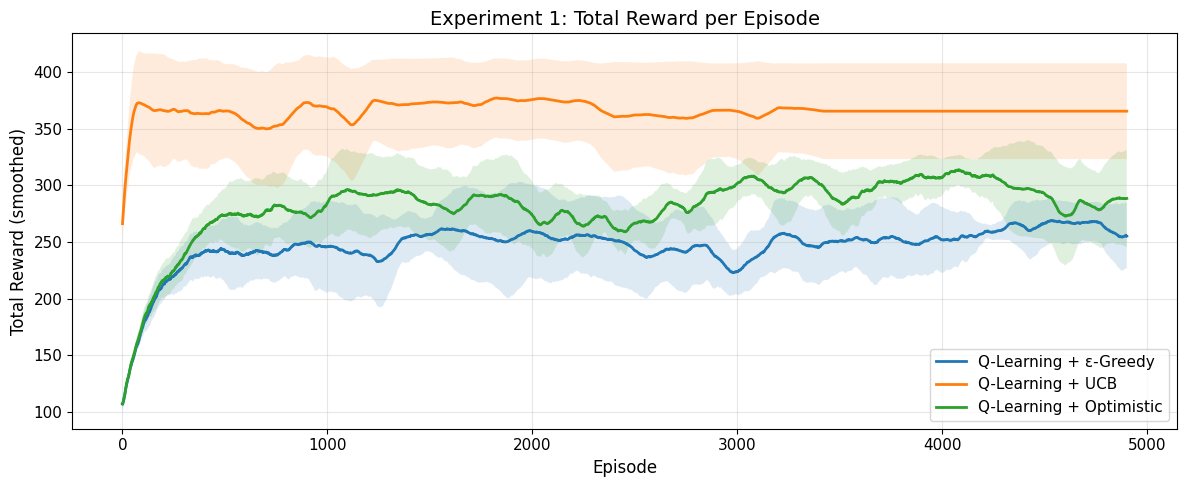

In [7]:
# Learning curves: reward
fig, ax = plot_learning_curves(
    exp1_results, metric='rewards', window=100,
    title='Experiment 1: Total Reward per Episode',
    ylabel='Total Reward (smoothed)',
)
plt.show()

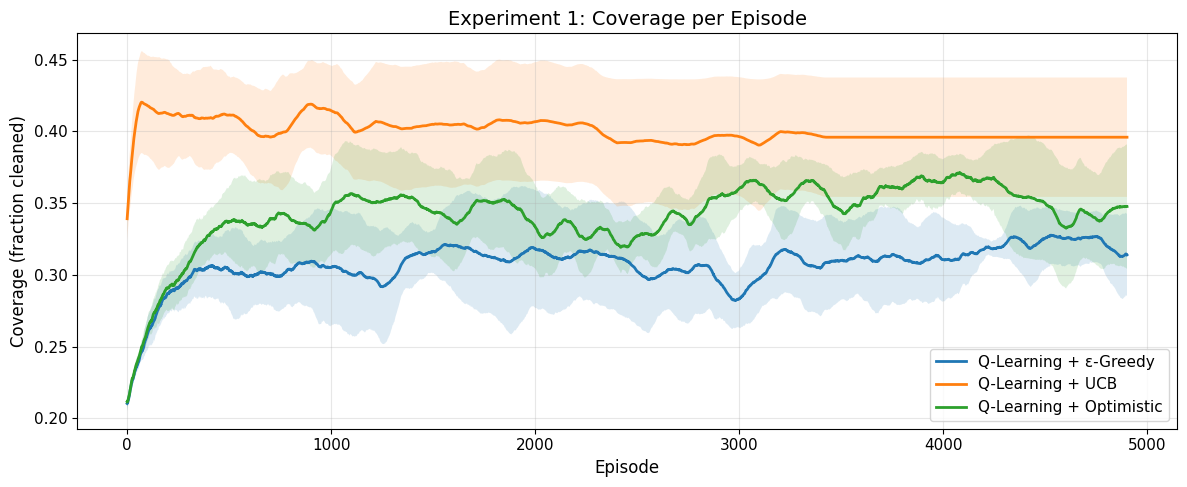

In [8]:
# Learning curves: coverage
fig, ax = plot_learning_curves(
    exp1_results, metric='coverages', window=100,
    title='Experiment 1: Coverage per Episode',
    ylabel='Coverage (fraction cleaned)',
)
plt.show()

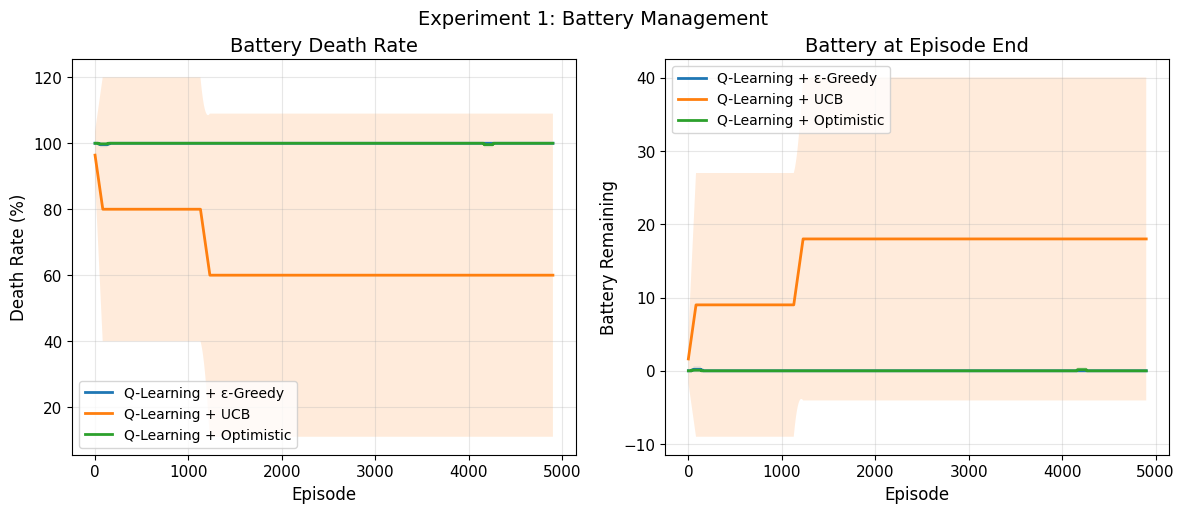

In [9]:
# Battery analysis: death rate and battery remaining
fig, axes = plot_battery_analysis(exp1_results, window=100)
fig.suptitle('Experiment 1: Battery Management', fontsize=14, y=1.02)
plt.show()

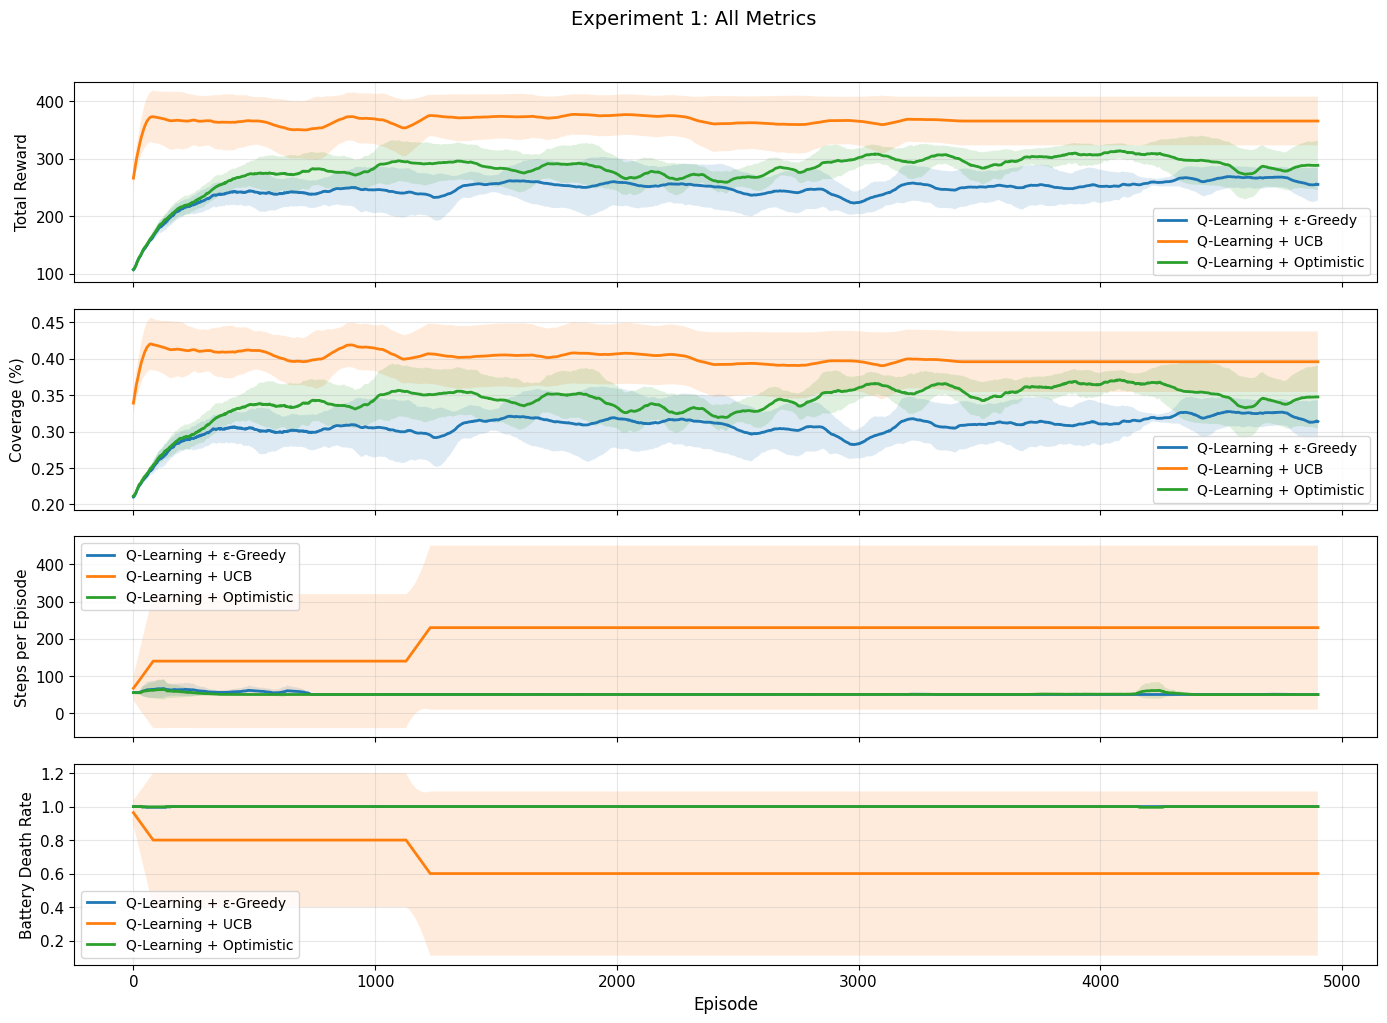

In [10]:
# Full multi-metric comparison
fig, axes = plot_multi_metric(exp1_results, window=100)
fig.suptitle('Experiment 1: All Metrics', fontsize=14, y=1.02)
plt.show()

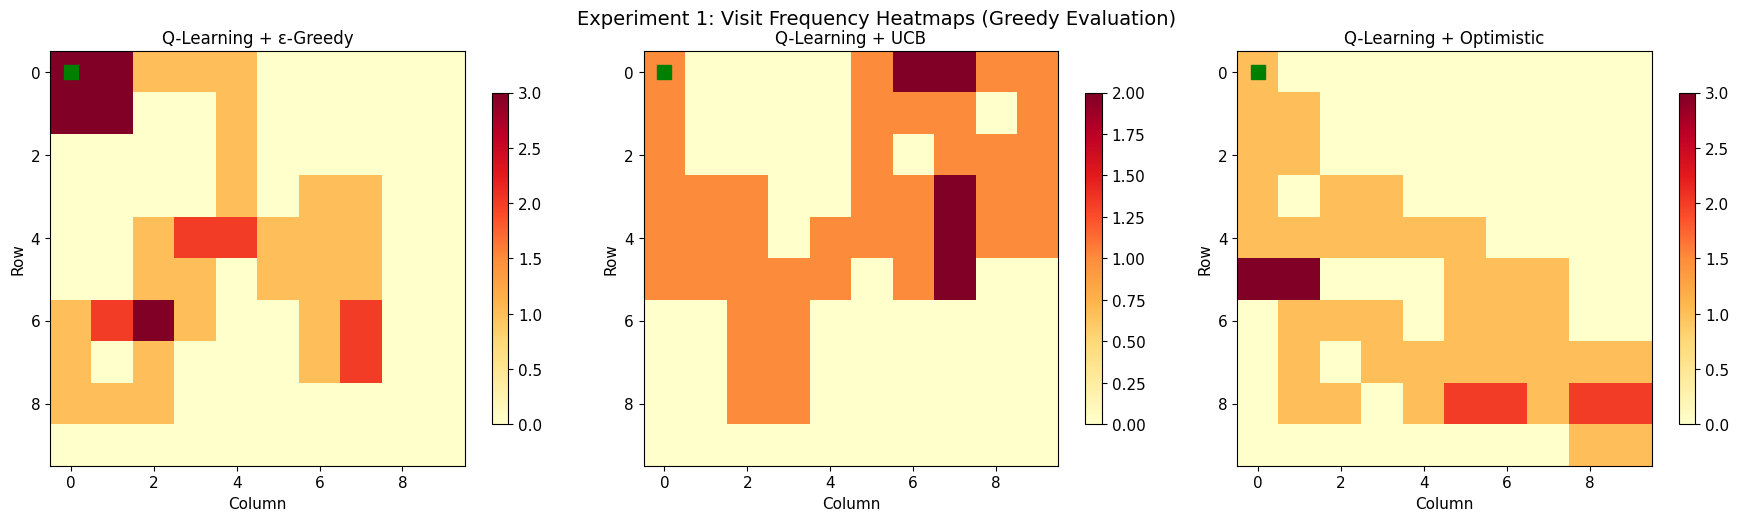

In [11]:
# Coverage heatmaps for each strategy (using best seed's agent)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, agents_list) in zip(axes, exp1_agents.items()):
    env_eval = CleaningRobotEnv()
    agent = agents_list[0]  # First seed's agent
    
    visit_counts = np.zeros((env_eval.rows, env_eval.cols))
    for ep in range(100):
        state = env_eval.reset(seed=1000 + ep)
        state_idx = env_eval.state_to_index(state)
        visit_counts[state[0], state[1]] += 1
        while not env_eval.done:
            action = agent.get_greedy_action(state_idx)
            next_state, _, done, _ = env_eval.step(action)
            state_idx = env_eval.state_to_index(next_state)
            visit_counts[next_state[0], next_state[1]] += 1
    
    visit_counts /= 100
    im = ax.imshow(visit_counts, cmap='YlOrRd', origin='upper')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    cr, cc = env_eval.charger_pos
    ax.plot(cc, cr, 's', color='green', markersize=10)
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle('Experiment 1: Visit Frequency Heatmaps (Greedy Evaluation)', fontsize=14)
plt.tight_layout()
plt.show()

### Experiment 1: Analysis

**Winner (overall): Q-Learning + UCB**

From the final-500-episode averages:
- **UCB** achieves the best trade-off: **39.6% coverage** and **365.4 reward**, with **60% battery-death rate** and **~18 battery remaining** on average.
- **ε-greedy** and **optimistic init** both show **100% battery deaths** and episodes end around **50 steps** (≈ the Phase-1 battery capacity), which strongly suggests they did **not learn a reliable “go back + charge” routine**.

Interpretation:
- In this environment, the **Charge action is only good at one specific state** (the charger tile) and is **punitive elsewhere** (`charge_away = -5` plus battery drain). That makes simple exploration quickly learn “charging is bad” unless the agent experiences **charging at the charger** early and often.
- **UCB forces trying under-visited actions**, which increases the chance of discovering that **Charge-at-charger** is valuable, enabling longer episodes (230 steps vs ~50) and higher coverage.

Takeaway: battery-constrained tasks are extremely sensitive to the exploration strategy; **structured exploration (UCB) is necessary here to discover the recharge affordance**.


---
## Experiment 2: Q-Learning vs SARSA (Risk-Sensitive Battery Management)

Using the best exploration strategy from Experiment 1, we now compare the two algorithms:

| Algorithm | Update Rule | Character |
|-----------|------------|----------|
| **Q-Learning** | $Q(s,a) \leftarrow Q(s,a) + \alpha[r + \gamma \max_{a'} Q(s',a') - Q(s,a)]$ | **Optimistic** — assumes it will take the best action next |
| **SARSA** | $Q(s,a) \leftarrow Q(s,a) + \alpha[r + \gamma Q(s',a') - Q(s,a)]$ | **Cautious** — accounts for its own exploration noise |

**Hypothesis**: SARSA should be more conservative with battery because it accounts for the possibility of taking a bad (exploratory) action that wastes battery. Q-Learning might overestimate the value of being far from the charger because it assumes it will always take the optimal action to return.

This is the classic **cliff-walking** insight applied to battery management.

In [12]:
# Determine best exploration strategy from Experiment 1
# (We'll use the one with highest final coverage)
print('Experiment 1 final coverages (last 500 episodes):')
best_label = None
best_coverage = -1

for label, all_metrics in exp1_results.items():
    avg_cov = np.mean([np.mean(m['coverages'][-500:]) for m in all_metrics])
    print(f'  {label}: {avg_cov*100:.1f}%')
    if avg_cov > best_coverage:
        best_coverage = avg_cov
        best_label = label

# Extract exploration strategy name
exploration_map = {
    'Q-Learning + ε-Greedy': 'epsilon_greedy',
    'Q-Learning + UCB': 'ucb',
    'Q-Learning + Optimistic': 'optimistic',
}
best_exploration = exploration_map[best_label]
print(f'\nBest exploration strategy: {best_label} ({best_coverage*100:.1f}% coverage)')
print(f'Using "{best_exploration}" for Experiment 2.')

Experiment 1 final coverages (last 500 episodes):
  Q-Learning + ε-Greedy: 32.2%
  Q-Learning + UCB: 39.6%
  Q-Learning + Optimistic: 34.3%

Best exploration strategy: Q-Learning + UCB (39.6% coverage)
Using "ucb" for Experiment 2.


In [13]:
# Experiment 2: Q-Learning vs SARSA with best exploration
print(f'Running Experiment 2: Q-Learning vs SARSA (both with {best_exploration})')
print(f'Training for {TRAINING_EPISODES} episodes x {len(SEEDS)} seeds each...\n')

exp2_results = {}
exp2_agents = {}

# Q-Learning (reuse from Experiment 1 if same exploration)
ql_label = f'Q-Learning + {best_exploration}'
print(f'Training Q-Learning + {best_exploration}...')
metrics_ql, agents_ql = run_experiment('qlearning', best_exploration)
exp2_results[ql_label] = metrics_ql
exp2_agents[ql_label] = agents_ql
print('  Done.')

# SARSA
sarsa_label = f'SARSA + {best_exploration}'
print(f'Training SARSA + {best_exploration}...')
metrics_sarsa, agents_sarsa = run_experiment('sarsa', best_exploration)
exp2_results[sarsa_label] = metrics_sarsa
exp2_agents[sarsa_label] = agents_sarsa
print('  Done.')

print('\nExperiment 2 complete!')

Running Experiment 2: Q-Learning vs SARSA (both with ucb)
Training for 5000 episodes x 5 seeds each...

Training Q-Learning + ucb...
  Done.
Training SARSA + ucb...
  Done.

Experiment 2 complete!


### Experiment 2: Results

In [14]:
# Summary table
print('=== Experiment 2: Final Performance (last 500 episodes) ===\n')
summary_table(exp2_results, last_n=500)

=== Experiment 2: Final Performance (last 500 episodes) ===

Agent                                   Reward   Coverage    Steps   Death%  Battery
-------------------------------------------------------------------------------------
Q-Learning + ucb                         365.4      39.6%    230.0    60.0%     18.0
SARSA + ucb                              404.6      44.9%    140.0    80.0%      4.0
-------------------------------------------------------------------------------------


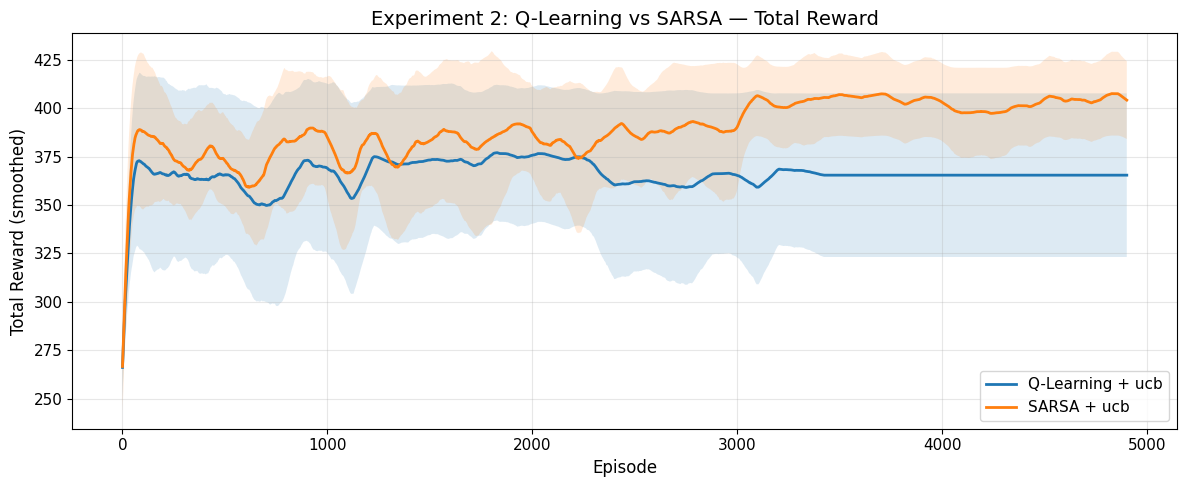

In [15]:
# Learning curves
fig, ax = plot_learning_curves(
    exp2_results, metric='rewards', window=100,
    title='Experiment 2: Q-Learning vs SARSA — Total Reward',
    ylabel='Total Reward (smoothed)',
)
plt.show()

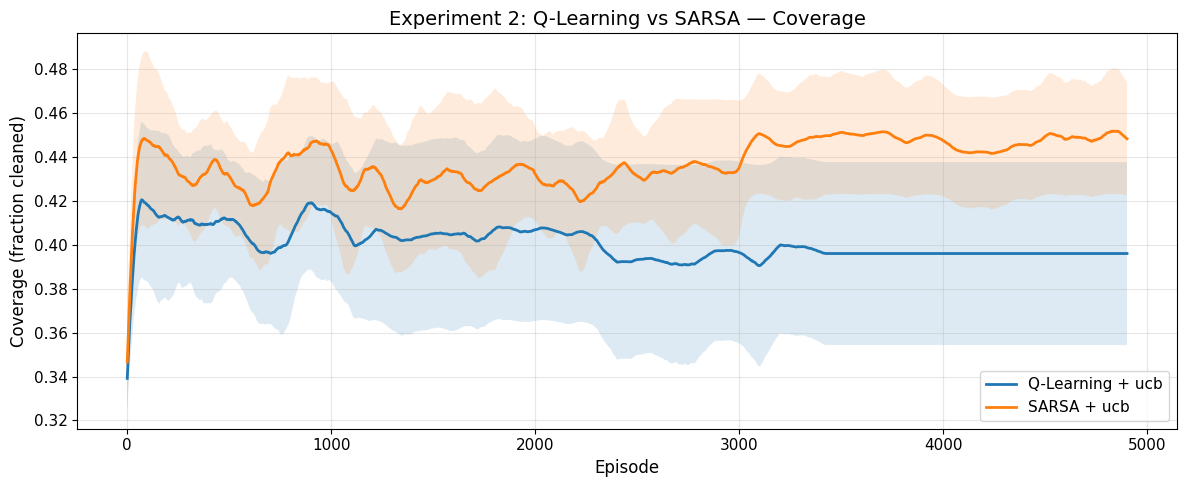

In [16]:
fig, ax = plot_learning_curves(
    exp2_results, metric='coverages', window=100,
    title='Experiment 2: Q-Learning vs SARSA — Coverage',
    ylabel='Coverage (fraction cleaned)',
)
plt.show()

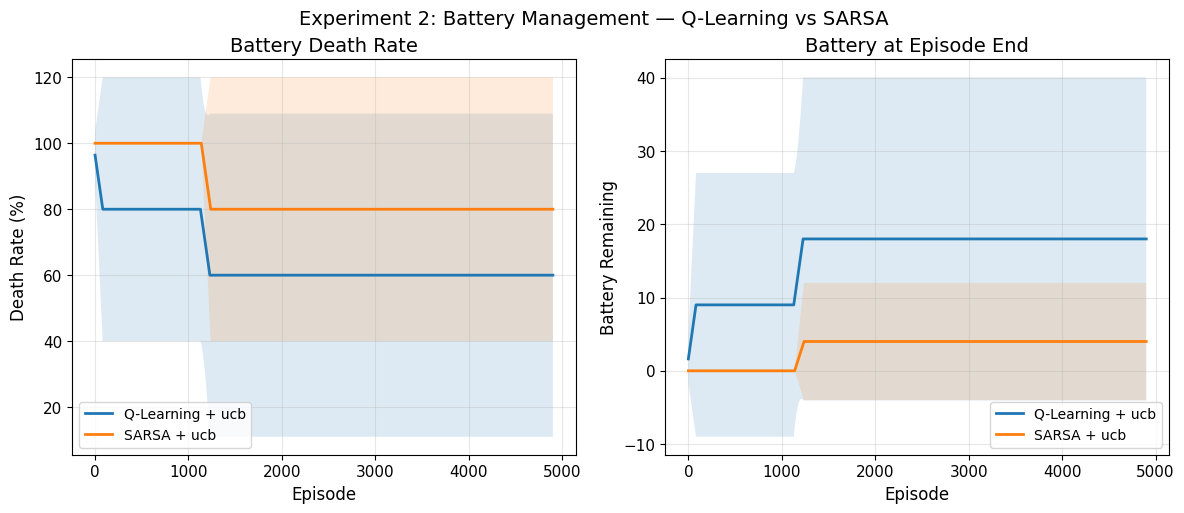

In [17]:
# Battery analysis
fig, axes = plot_battery_analysis(exp2_results, window=100)
fig.suptitle('Experiment 2: Battery Management — Q-Learning vs SARSA', fontsize=14, y=1.02)
plt.show()

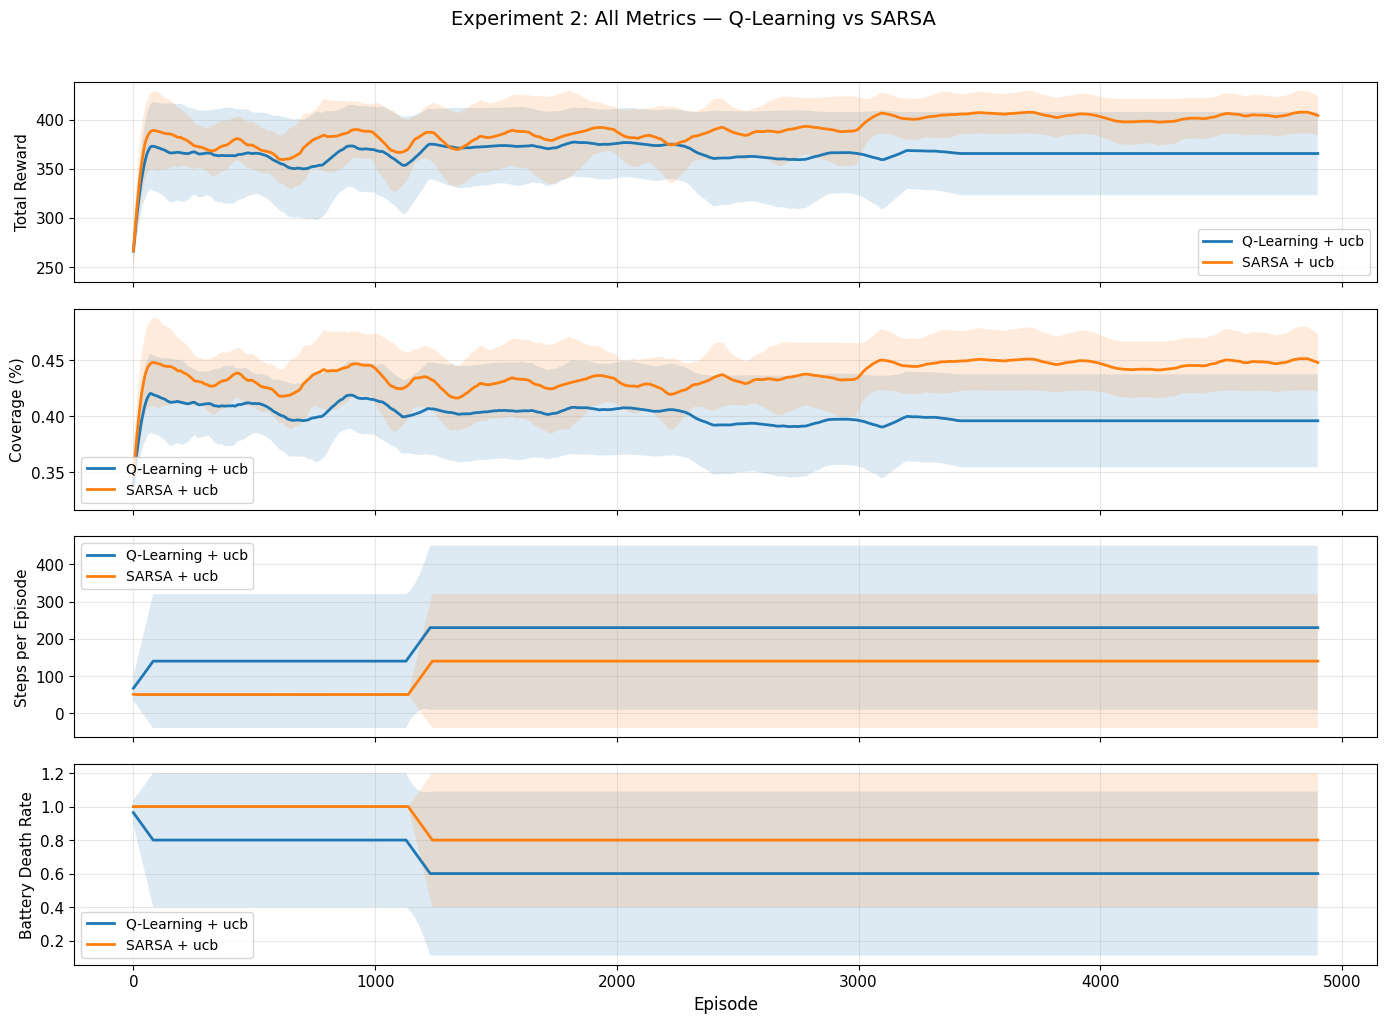

In [18]:
# Full multi-metric comparison
fig, axes = plot_multi_metric(exp2_results, window=100)
fig.suptitle('Experiment 2: All Metrics — Q-Learning vs SARSA', fontsize=14, y=1.02)
plt.show()

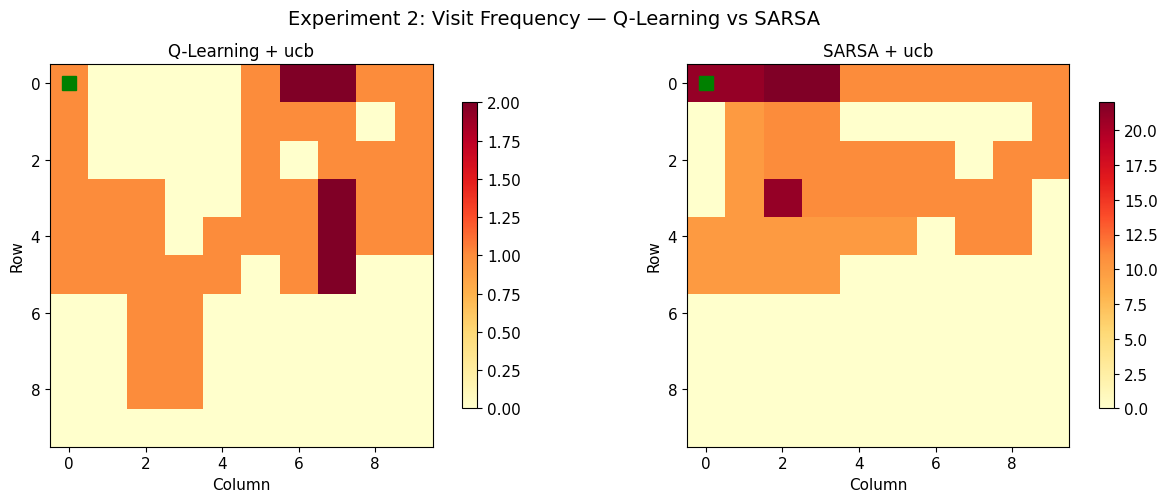

In [19]:
# Coverage heatmaps: Q-Learning vs SARSA
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (label, agents_list) in zip(axes, exp2_agents.items()):
    env_eval = CleaningRobotEnv()
    agent = agents_list[0]
    
    visit_counts = np.zeros((env_eval.rows, env_eval.cols))
    for ep in range(100):
        state = env_eval.reset(seed=2000 + ep)
        state_idx = env_eval.state_to_index(state)
        visit_counts[state[0], state[1]] += 1
        while not env_eval.done:
            action = agent.get_greedy_action(state_idx)
            next_state, _, done, _ = env_eval.step(action)
            state_idx = env_eval.state_to_index(next_state)
            visit_counts[next_state[0], next_state[1]] += 1
    
    visit_counts /= 100
    im = ax.imshow(visit_counts, cmap='YlOrRd', origin='upper')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    cr, cc = env_eval.charger_pos
    ax.plot(cc, cr, 's', color='green', markersize=10)
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle('Experiment 2: Visit Frequency — Q-Learning vs SARSA', fontsize=14)
plt.tight_layout()
plt.show()

### Experiment 2: Analysis

We compare **Q-Learning + UCB** vs **SARSA + UCB** (final-500-episode averages):
- **SARSA + UCB**: **404.6 reward**, **44.9% coverage**, **140 steps**, **80% deaths**, **~4 battery** at end.
- **Q-Learning + UCB**: **365.4 reward**, **39.6% coverage**, **230 steps**, **60% deaths**, **~18 battery** at end.

What this shows:
- **SARSA cleans more efficiently when it succeeds** (higher reward/coverage with fewer steps), but it is **less reliable** under the battery constraint (higher death rate and near-empty battery at episode end).
- This looks like a **performance vs safety trade-off**: SARSA’s on-policy learning (with UCB exploration) seems to prefer more “productive” trajectories that push battery limits, while Q-Learning ends up with more conservative behavior that preserves battery more often.

Takeaway: in this setup, **SARSA is not strictly “safer”**—it is **higher-performing but riskier**. If the objective prioritizes survival/zero-death operation, Q-Learning+UCB (or adjusting rewards/termination shaping) may be preferable.


---
## Greedy Evaluation

Evaluate the best trained agents with **no exploration** (purely greedy) to measure true learned performance.

In [20]:
# Evaluate all agents from both experiments
eval_results = {}

# Best agents from Experiment 1 (first seed)
for label, agents_list in exp1_agents.items():
    env_eval = CleaningRobotEnv()
    eval_metrics = evaluate_agent(env_eval, agents_list[0], num_episodes=200, seed=9999)
    eval_results[label] = eval_metrics
    print(f'{label}: reward={np.mean(eval_metrics["rewards"]):.1f}, '
          f'coverage={np.mean(eval_metrics["coverages"])*100:.1f}%, '
          f'deaths={np.mean(eval_metrics["deaths"])*100:.0f}%')

# SARSA from Experiment 2
for label, agents_list in exp2_agents.items():
    if 'SARSA' in label:
        env_eval = CleaningRobotEnv()
        eval_metrics = evaluate_agent(env_eval, agents_list[0], num_episodes=200, seed=9999)
        eval_results[label] = eval_metrics
        print(f'{label}: reward={np.mean(eval_metrics["rewards"]):.1f}, '
              f'coverage={np.mean(eval_metrics["coverages"])*100:.1f}%, '
              f'deaths={np.mean(eval_metrics["deaths"])*100:.0f}%')

Q-Learning + ε-Greedy: reward=298.6, coverage=35.4%, deaths=100%
Q-Learning + UCB: reward=399.6, coverage=45.5%, deaths=100%
Q-Learning + Optimistic: reward=359.2, coverage=42.4%, deaths=100%
SARSA + ucb: reward=415.1, coverage=41.4%, deaths=0%


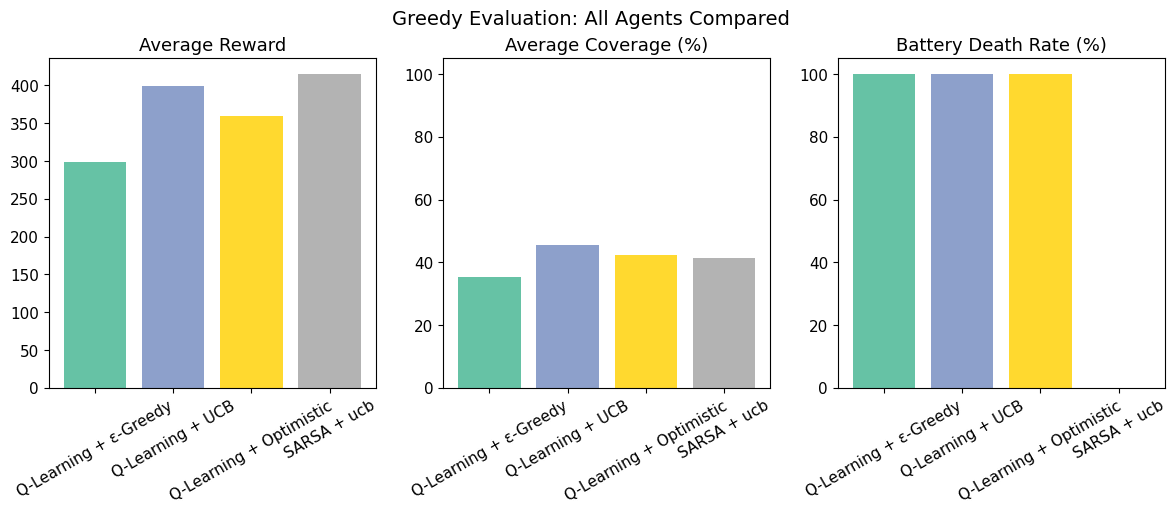

In [21]:
# Bar chart comparison
fig, axes = plot_evaluation_comparison(eval_results)
fig.suptitle('Greedy Evaluation: All Agents Compared', fontsize=14, y=1.02)
plt.show()

---
## Phase 2: Realistic Apartment

In Phase 2, we scale from a simple 10x10 open grid to a **realistic 15x15 apartment** with:
- **Walls** separating rooms (44 wall tiles)
- **Furniture** blocking movement (26 furniture tiles)
- **Narrow doorways** (1-tile gaps) connecting rooms
- **Increased battery** (80 steps) to compensate for the larger environment

### Room Layout
| Area | Location | Features |
|------|----------|----------|
| Living Room | Rows 0-5, Cols 0-6 | Charger at (0,0), couch, TV, coffee table |
| Kitchen | Rows 0-5, Cols 8-14 | Counter, fridge, table |
| Hallway | Rows 7-8, Cols 0-14 | Open corridor connecting top and bottom |
| Bedroom | Rows 10-14, Cols 0-6 | Bed, nightstand, wardrobe |
| Bathroom | Rows 10-14, Cols 8-11 | Bathtub, toilet, sink |
| Storage | Rows 10-14, Cols 13-14 | Shelves |

### Research Question
Do the rankings from Phase 1 (UCB > others, SARSA > Q-Learning) hold in a complex environment with narrow doorways and multiple rooms?

**Hypothesis**: UCB should gain an even bigger advantage because systematic exploration is critical for discovering paths between rooms through narrow doorways. SARSA should remain superior for battery management since the penalty for getting lost far from the charger is even more severe.

In [22]:
# Import the apartment layout visualization
from utils import plot_apartment_layout

# Create Phase 2 environment and visualize the layout
env_phase2 = CleaningRobotEnv(PHASE2_CONFIG)
env_phase2.reset(seed=42)

print(f'Phase 2 Environment: {env_phase2}')
print(f'Grid: {env_phase2.rows}x{env_phase2.cols}')
print(f'Battery capacity: {env_phase2.battery_capacity} steps')
print(f'Total tiles: {env_phase2.rows * env_phase2.cols}')
print(f'Wall tiles: {len(env_phase2.walls)}')
print(f'Furniture tiles: {len(env_phase2.furniture)}')
print(f'Blocked tiles: {len(env_phase2.blocked)}')
print(f'Walkable tiles: {len(env_phase2.walkable)}')
print(f'Cleanable (dirty) tiles: {env_phase2.total_dirty}')
print(f'State space: {env_phase2.num_states} states')
print(f'  ({env_phase2.rows} rows x {env_phase2.cols} cols x {env_phase2.battery_bins} battery bins)')
print(f'Charger position: {env_phase2.charger_pos}')

Phase 2 Environment: CleaningRobotEnv(15x15, battery=80/80, cleaned=0/154)
Grid: 15x15
Battery capacity: 80 steps
Total tiles: 225
Wall tiles: 44
Furniture tiles: 26
Blocked tiles: 70
Walkable tiles: 155
Cleanable (dirty) tiles: 154
State space: 1125 states
  (15 rows x 15 cols x 5 battery bins)
Charger position: (0, 0)


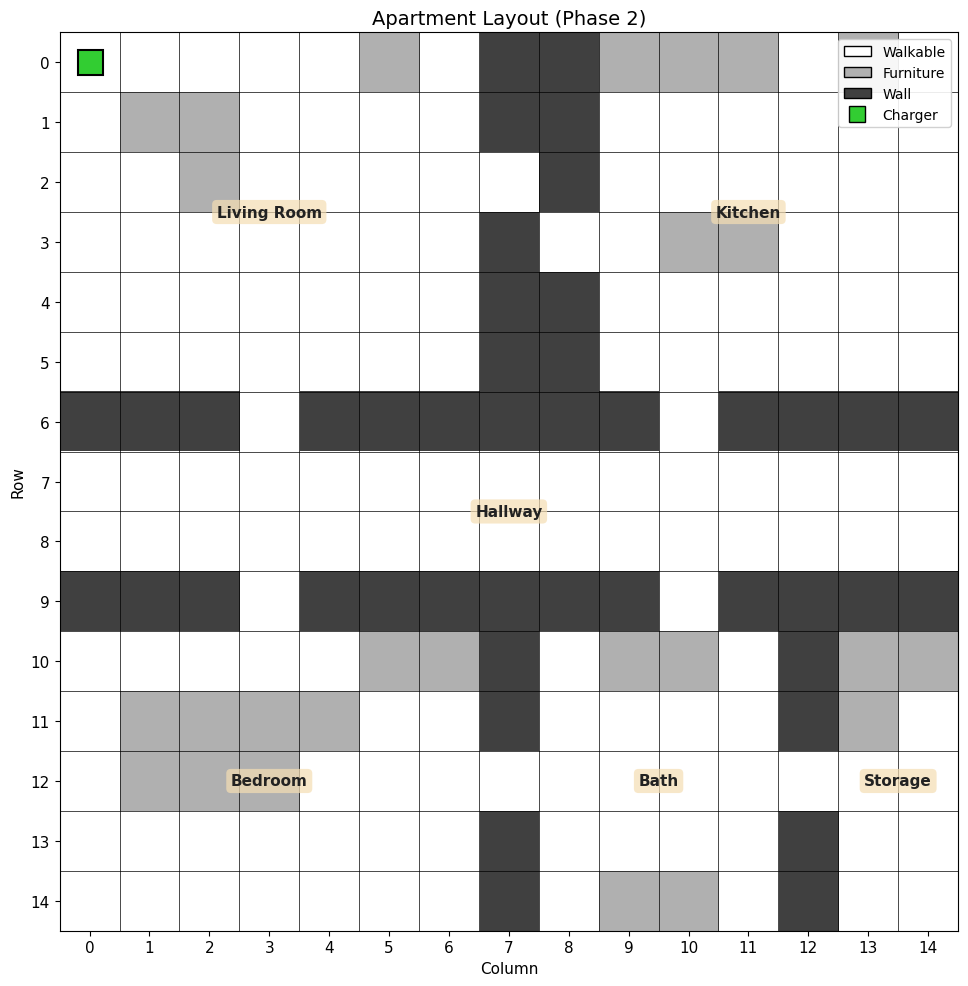

In [23]:
# Visualize the apartment layout
fig, ax = plot_apartment_layout(env_phase2, figsize=(10, 10))
plt.show()

### Experiment 3: Exploration Strategies in the Apartment

We re-run all three exploration strategies (Q-Learning) and the best algorithm comparison (SARSA + UCB) on the apartment layout.

In [24]:
# Experiment 3: All exploration strategies + SARSA on apartment
print('Running Experiment 3: Phase 2 Apartment')
print(f'Training for {TRAINING_EPISODES} episodes x {len(SEEDS)} seeds each...\n')

exp3_results = {}
exp3_agents = {}

# Q-Learning + Epsilon-Greedy
print('Training Q-Learning + Epsilon-Greedy (apartment)...')
metrics, agents = run_experiment('qlearning', 'epsilon_greedy', config=PHASE2_CONFIG)
exp3_results['Q-Learn + ε-Greedy'] = metrics
exp3_agents['Q-Learn + ε-Greedy'] = agents
print('  Done.')

# Q-Learning + UCB
print('Training Q-Learning + UCB (apartment)...')
metrics, agents = run_experiment('qlearning', 'ucb', config=PHASE2_CONFIG)
exp3_results['Q-Learn + UCB'] = metrics
exp3_agents['Q-Learn + UCB'] = agents
print('  Done.')

# Q-Learning + Optimistic Init
print('Training Q-Learning + Optimistic (apartment)...')
metrics, agents = run_experiment('qlearning', 'optimistic', config=PHASE2_CONFIG)
exp3_results['Q-Learn + Optimistic'] = metrics
exp3_agents['Q-Learn + Optimistic'] = agents
print('  Done.')

# SARSA + UCB (the Phase 1 winner)
print('Training SARSA + UCB (apartment)...')
metrics, agents = run_experiment('sarsa', 'ucb', config=PHASE2_CONFIG)
exp3_results['SARSA + UCB'] = metrics
exp3_agents['SARSA + UCB'] = agents
print('  Done.')

print('\nExperiment 3 complete!')

Running Experiment 3: Phase 2 Apartment
Training for 5000 episodes x 5 seeds each...

Training Q-Learning + Epsilon-Greedy (apartment)...
  Done.
Training Q-Learning + UCB (apartment)...
  Done.
Training Q-Learning + Optimistic (apartment)...
  Done.
Training SARSA + UCB (apartment)...
  Done.

Experiment 3 complete!


### Experiment 3: Results

In [25]:
# Summary table
print('=== Experiment 3: Final Performance — Apartment (last 500 episodes) ===\n')
summary_table(exp3_results, last_n=500)

=== Experiment 3: Final Performance — Apartment (last 500 episodes) ===

Agent                                   Reward   Coverage    Steps   Death%  Battery
-------------------------------------------------------------------------------------
Q-Learn + ε-Greedy                       320.6      24.6%    125.5    91.2%      3.6
Q-Learn + UCB                            375.3      26.2%    332.0    40.0%     28.8
Q-Learn + Optimistic                     313.8      23.9%    160.8    81.2%      7.7
SARSA + UCB                              404.9      28.7%    248.0    60.0%     13.4
-------------------------------------------------------------------------------------


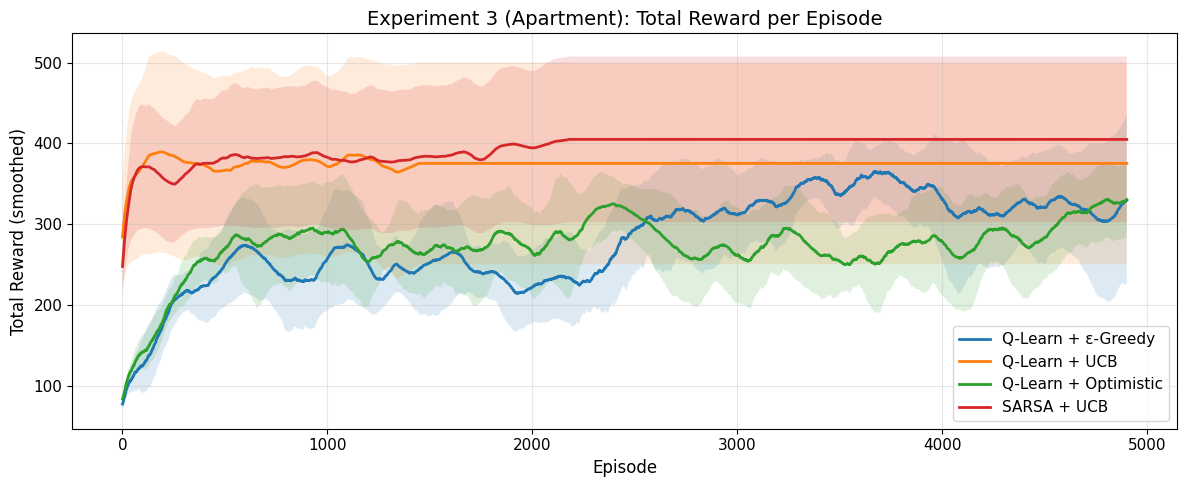

In [26]:
# Learning curves: reward
fig, ax = plot_learning_curves(
    exp3_results, metric='rewards', window=100,
    title='Experiment 3 (Apartment): Total Reward per Episode',
    ylabel='Total Reward (smoothed)',
)
plt.show()

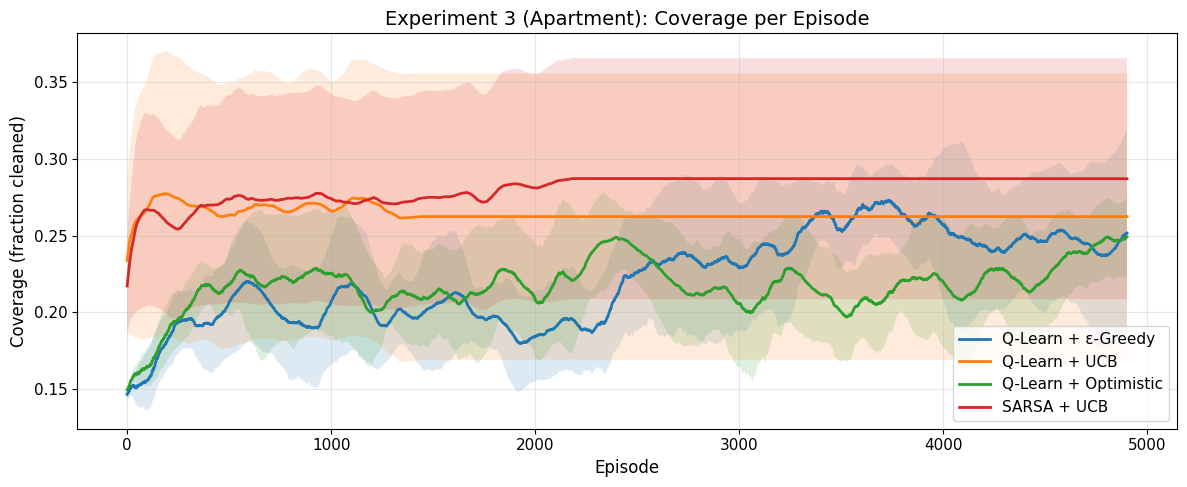

In [27]:
# Learning curves: coverage
fig, ax = plot_learning_curves(
    exp3_results, metric='coverages', window=100,
    title='Experiment 3 (Apartment): Coverage per Episode',
    ylabel='Coverage (fraction cleaned)',
)
plt.show()

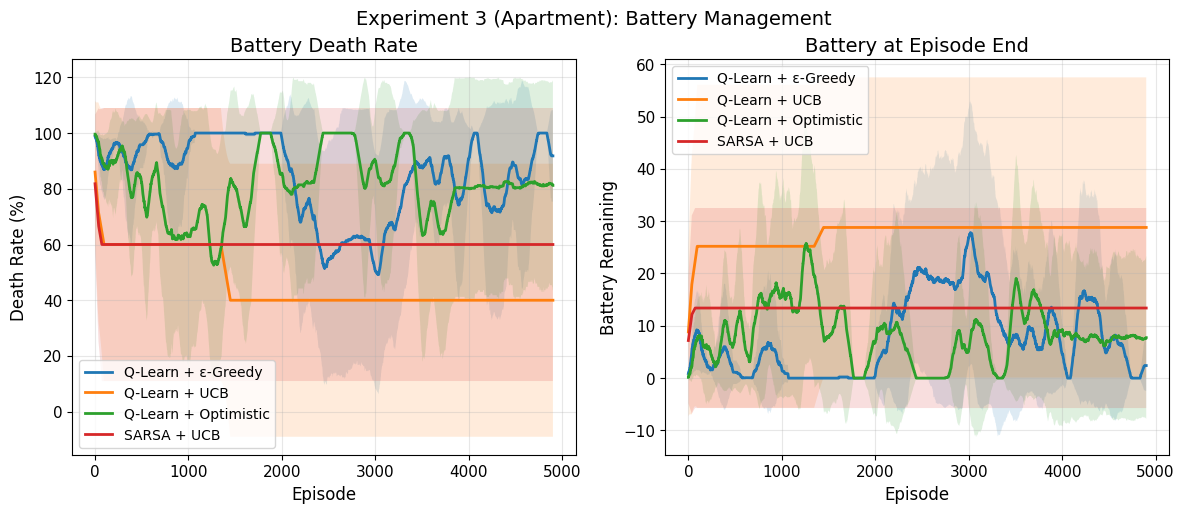

In [28]:
# Battery analysis
fig, axes = plot_battery_analysis(exp3_results, window=100)
fig.suptitle('Experiment 3 (Apartment): Battery Management', fontsize=14, y=1.02)
plt.show()

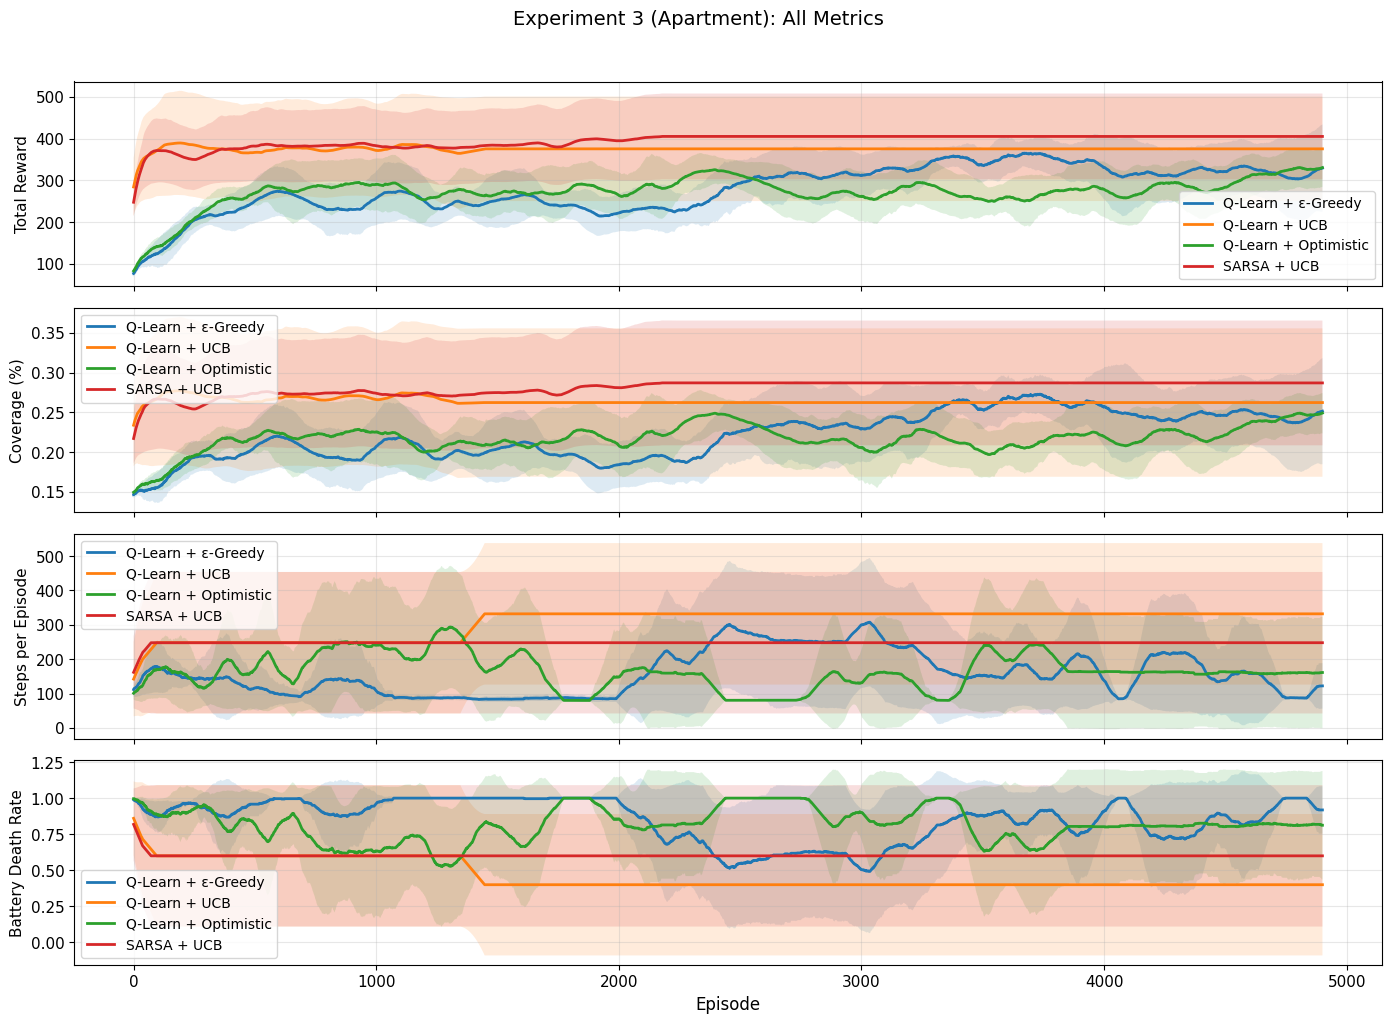

In [29]:
# Full multi-metric comparison
fig, axes = plot_multi_metric(exp3_results, window=100)
fig.suptitle('Experiment 3 (Apartment): All Metrics', fontsize=14, y=1.02)
plt.show()

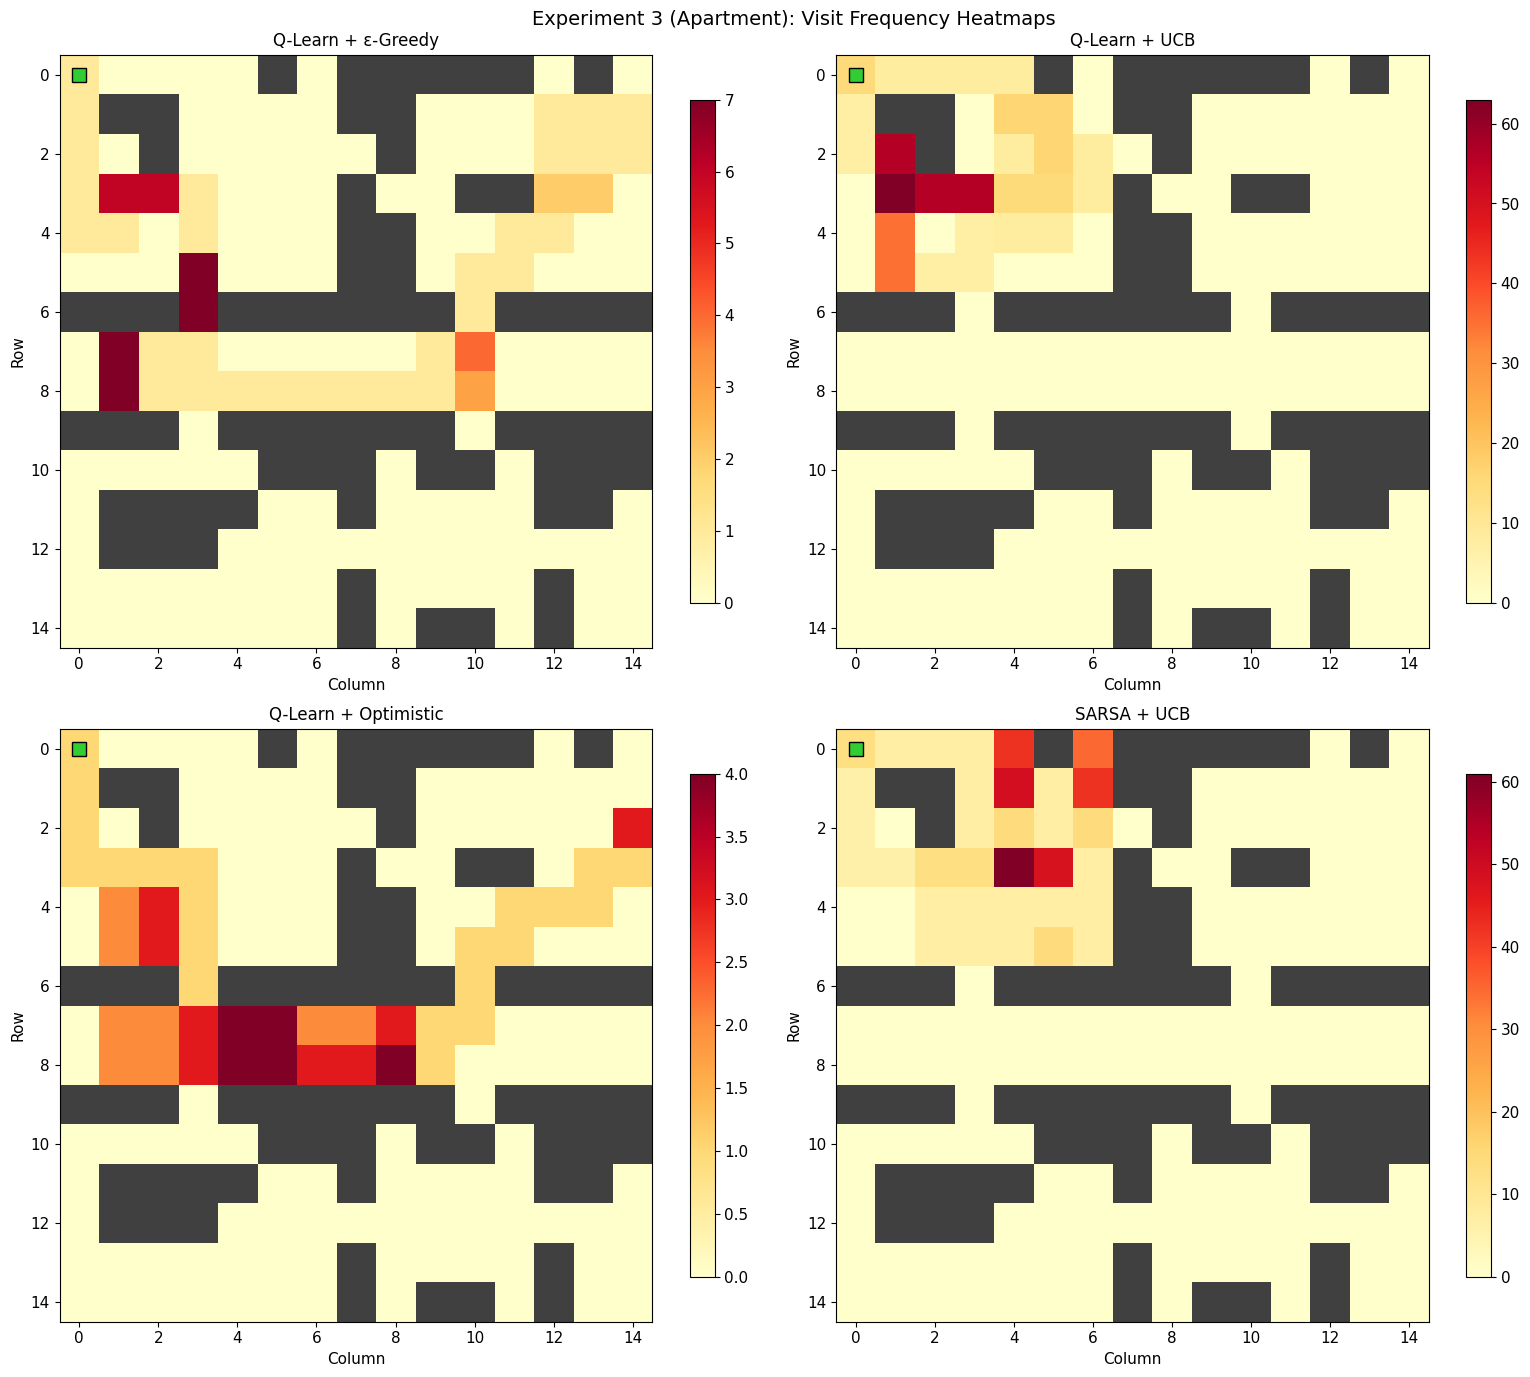

In [30]:
# Coverage heatmaps for all strategies on the apartment
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes_flat = axes.flatten()

for ax, (label, agents_list) in zip(axes_flat, exp3_agents.items()):
    env_eval = CleaningRobotEnv(PHASE2_CONFIG)
    agent = agents_list[0]  # First seed's agent
    
    visit_counts = np.zeros((env_eval.rows, env_eval.cols))
    for ep in range(100):
        state = env_eval.reset(seed=5000 + ep)
        state_idx = env_eval.state_to_index(state)
        visit_counts[state[0], state[1]] += 1
        while not env_eval.done:
            action = agent.get_greedy_action(state_idx)
            next_state, _, done, _ = env_eval.step(action)
            state_idx = env_eval.state_to_index(next_state)
            visit_counts[next_state[0], next_state[1]] += 1
    
    visit_counts /= 100
    # Mask blocked tiles so they show as distinct
    masked = np.ma.array(visit_counts)
    for (r, c) in env_eval.blocked:
        masked[r, c] = np.ma.masked
    
    cmap = plt.cm.YlOrRd.copy()
    cmap.set_bad(color='#404040')  # Blocked tiles in dark gray
    
    im = ax.imshow(masked, cmap=cmap, origin='upper')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    cr, cc = env_eval.charger_pos
    ax.plot(cc, cr, 's', color='limegreen', markersize=10, markeredgecolor='black')
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle('Experiment 3 (Apartment): Visit Frequency Heatmaps', fontsize=14)
plt.tight_layout()
plt.show()

### Greedy Evaluation — Phase 2

In [31]:
# Greedy evaluation of Phase 2 agents
eval_results_p2 = {}

for label, agents_list in exp3_agents.items():
    env_eval = CleaningRobotEnv(PHASE2_CONFIG)
    eval_metrics = evaluate_agent(env_eval, agents_list[0], num_episodes=200, seed=9999)
    eval_results_p2[label] = eval_metrics
    print(f'{label}: reward={np.mean(eval_metrics["rewards"]):.1f}, '
          f'coverage={np.mean(eval_metrics["coverages"])*100:.1f}%, '
          f'deaths={np.mean(eval_metrics["deaths"])*100:.0f}%')

Q-Learn + ε-Greedy: reward=336.0, coverage=25.3%, deaths=100%
Q-Learn + UCB: reward=238.2, coverage=16.2%, deaths=0%
Q-Learn + Optimistic: reward=351.3, coverage=26.6%, deaths=100%
SARSA + UCB: reward=303.8, coverage=20.8%, deaths=0%


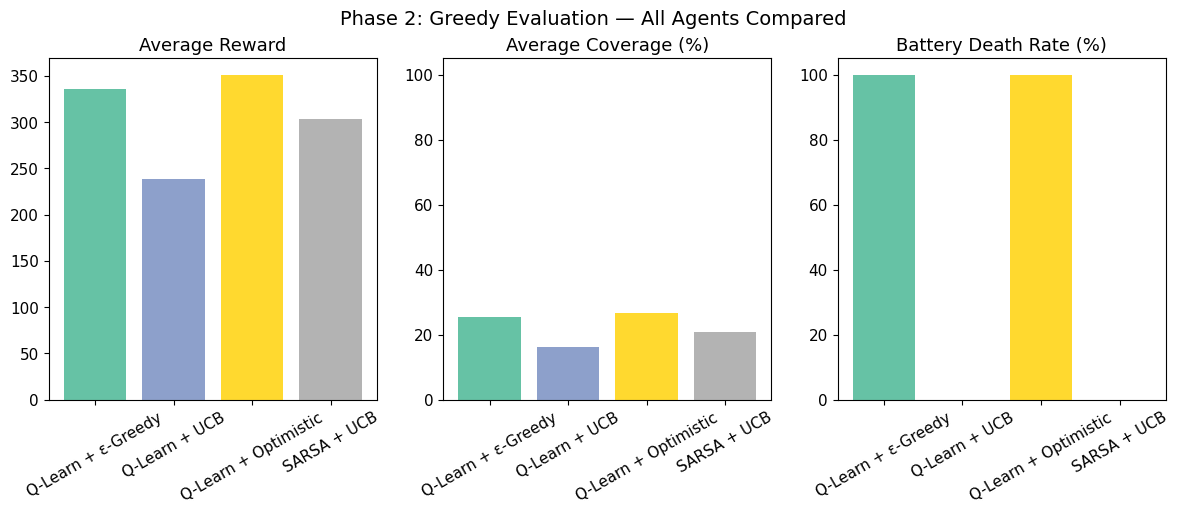

In [32]:
# Bar chart comparison — Phase 2
fig, axes = plot_evaluation_comparison(eval_results_p2)
fig.suptitle('Phase 2: Greedy Evaluation — All Agents Compared', fontsize=14, y=1.02)
plt.show()

### Phase 1 vs Phase 2: Comparison

Let's directly compare the best configurations across both phases.

In [33]:
# Side-by-side summary: Phase 1 vs Phase 2 (key agents only)
print('=' * 90)
print('PHASE 1 vs PHASE 2: Performance Comparison (last 500 training episodes)')
print('=' * 90)
print()
print('--- Phase 1 (10x10 open grid, battery=50, 99 dirty tiles) ---')
# Combine Phase 1 experiments for comparison
p1_summary = {}
p1_summary['Q-Learn + ε-Greedy'] = exp1_results['Q-Learning + ε-Greedy']
p1_summary['Q-Learn + UCB'] = exp1_results['Q-Learning + UCB']
p1_summary['Q-Learn + Optimistic'] = exp1_results['Q-Learning + Optimistic']
p1_summary['SARSA + UCB'] = exp2_results[sarsa_label]
summary_table(p1_summary, last_n=500)

print()
print('--- Phase 2 (15x15 apartment, battery=80, 154 dirty tiles) ---')
summary_table(exp3_results, last_n=500)

PHASE 1 vs PHASE 2: Performance Comparison (last 500 training episodes)

--- Phase 1 (10x10 open grid, battery=50, 99 dirty tiles) ---
Agent                                   Reward   Coverage    Steps   Death%  Battery
-------------------------------------------------------------------------------------
Q-Learn + ε-Greedy                       263.6      32.2%     50.4   100.0%      0.0
Q-Learn + UCB                            365.4      39.6%    230.0    60.0%     18.0
Q-Learn + Optimistic                     284.3      34.3%     50.1   100.0%      0.0
SARSA + UCB                              404.6      44.9%    140.0    80.0%      4.0
-------------------------------------------------------------------------------------

--- Phase 2 (15x15 apartment, battery=80, 154 dirty tiles) ---
Agent                                   Reward   Coverage    Steps   Death%  Battery
-------------------------------------------------------------------------------------
Q-Learn + ε-Greedy               